In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
print(data.shape)
print(data.info())
print(data.describe())

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       200 non-null    int64  
 1   education_years  200 non-null    int64  
 2   age              200 non-null    int64  
 3   salary           200 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 6.4 KB
None
       experience  education_years         age         salary
count  200.000000       200.000000  200.000000     200.000000
mean     4.560000        14.325000   41.090000   98662.338910
std      2.899731         2.943245   10.903501   16873.123936
min      0.000000        10.000000   22.000000   41718.307864
25%      2.000000        12.000000   32.000000   87609.188628
50%      5.000000        14.000000   41.000000   98242.821145
75%      7.000000        17.000000   50.000000  109187.914075
max      9.000000        19.000000   59.000000  144495.96647

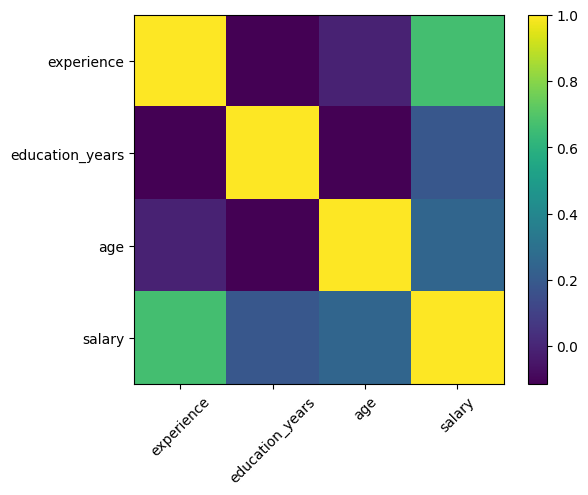

In [7]:
corr=data.corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns,rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

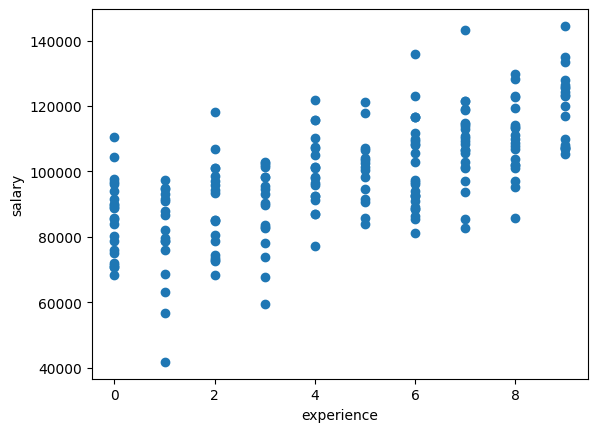

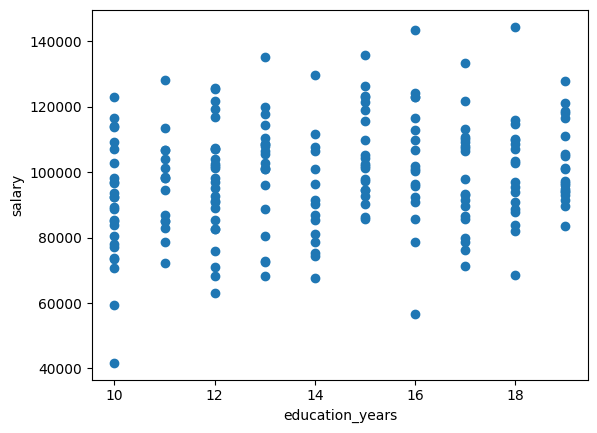

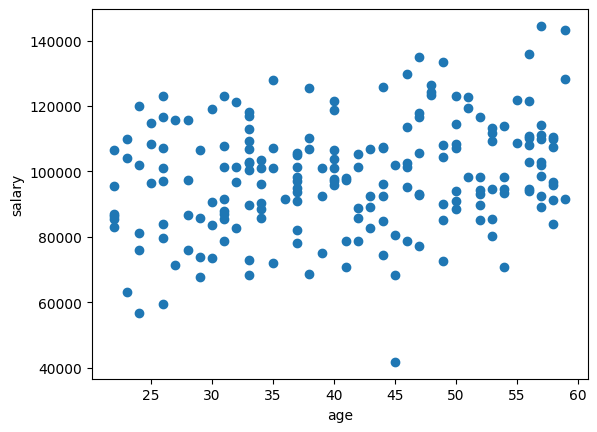

In [8]:
features=["experience","education_years","age"]
for col in features:
  plt.figure()
  plt.scatter(data[col],data["salary"])
  plt.xlabel(col)
  plt.ylabel("salary")
  plt.show()

In [2]:
np.random.seed(42)
n=200
data= pd.DataFrame({
    "experience": np.random.randint(0, 10, n),
    "education_years": np.random.randint(10, 20, n),
    "age":np.random.randint(22,60,n)
})

data["salary"] = (
     30000 +
    data["experience"] * 4000 +
    data["education_years"]*2000 +
    data["age"] * 500 +
    np.random.randn(n) * 10000
)

data.head()

,experience,education_years,age,salary
0,6,15,22,86244.382120
1,3,10,37,78151.516664
2,7,18,26,97127.707923
3,4,15,43,92588.364713
4,6,12,50,90908.776104


In [10]:
x=data[["experience",'education_years','age']]
y=data['salary']

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [12]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [15]:
print(model.coef_)
print(model.intercept_)

[3982.68630284 1812.43593196  448.92724357]
34654.865163775066


In [14]:
y_pred=model.predict(X_test)

In [16]:
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MSE: 131136284.7948535
RMSE: 11451.4752235183


In [17]:
new_data=pd.DataFrame({
    "experience":[5],
    "education_years":[15],
    "age":[30]
})
print(model.predict(new_data))


[95222.65296459]
